In [19]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys # Add the module path. Windows and Linux use different path separators; the raw string prevents escape sequences such as \n from being interpreted.
sys.path.insert(0, r"../main_code/3d")
for _mod in ['generate_data', 'mesh', 'adaptive_int', 'visual', 'matrix_assemble', 'inverse_solver', 'mea_3d', 'net_3d', 'source_eval', 'error_general_3d', 'main', 'bound_detect', 'q_filter']:
    sys.modules.pop(_mod, None)
import generate_data,mesh,visual,matrix_assemble,inverse_solver,mea_3d,net_3d,source_eval,error_general_3d
CUDA_LAUNCH_BLOCKING=2

def ana_S(x, center,R, r, S0):
    x1=x[:,0]
    
    x2=x[:,1]
    x3=x[:,2]
    cx, cy, cz = center[0,0],center[0,1],center[0,2]
    
    # Compute whether each point lies inside the torus relative to the shifted center.
    
    x_rel, y_rel, z_rel = x1 - cx, x2 - cy, x3 - cz
    condition = (np.sqrt(x_rel**2 + y_rel**2) - R)**2 + z_rel**2 <= r**2
    
    # Use np.where to return S0 or 0 according to the condition.
    return np.where(condition, S0, 0.0)

cuda:2


In [20]:
import numpy as np
import matplotlib.pyplot as plt
S_num_5=np.load("./noise=5%/S_num.npy")

# Create data
x = np.linspace(-0.5, 0.5, 301)
y = np.linspace(-0.5, 0.5, 301)
z = np.linspace(-0.5, 0.5, 301)
X, Y, Z = np.meshgrid(x, y,z,indexing='ij')
samples=np.vstack((X.ravel(),Y.ravel(),Z.ravel())).T
center_true=np.array([[0.0,0.0,0.0]])
R_true = 0.25   
r_true = 0.15
S0= 1.0 
S_true=ana_S(samples,center_true,R_true, r_true, S0).reshape(301,301,301)



In [21]:
S_num_x1_mid=S_num_5[int(0.5*S_num_5.shape[0])+1-1,:,:]
S_true_x1_mid=S_true[int(0.5*S_true.shape[0])+1-1,:,:]
S_num_x2_mid=S_num_5[:,int(0.5*S_num_5.shape[2])+1-1,:]
S_true_x2_mid=S_true[:,int(0.5*S_true.shape[2])+1-1,:]
S_num_x3_mid=S_num_5[:,:,int(0.5*S_num_5.shape[0])+1-1]
S_true_x3_mid=S_true[:,:,int(0.5*S_true.shape[0])+1-1]


In [22]:
YY,ZZ=np.meshgrid(y, z,indexing='ij')
XX,ZZ=np.meshgrid(x, z,indexing='ij')

Plot saved as ./noise=5%/visual/ex4.9_S_true_x1_mid.pdf


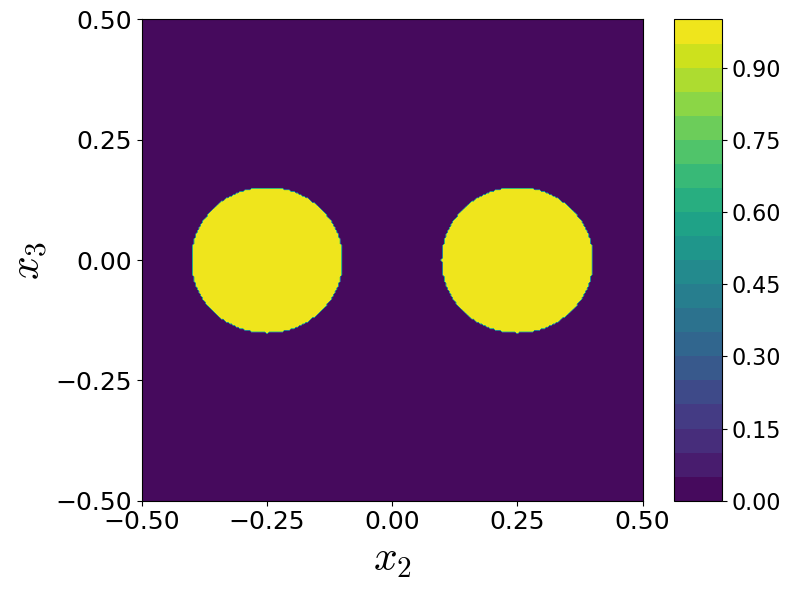

Plot saved as ./noise=5%/visual/ex4.9_S_num_x1_mid.pdf


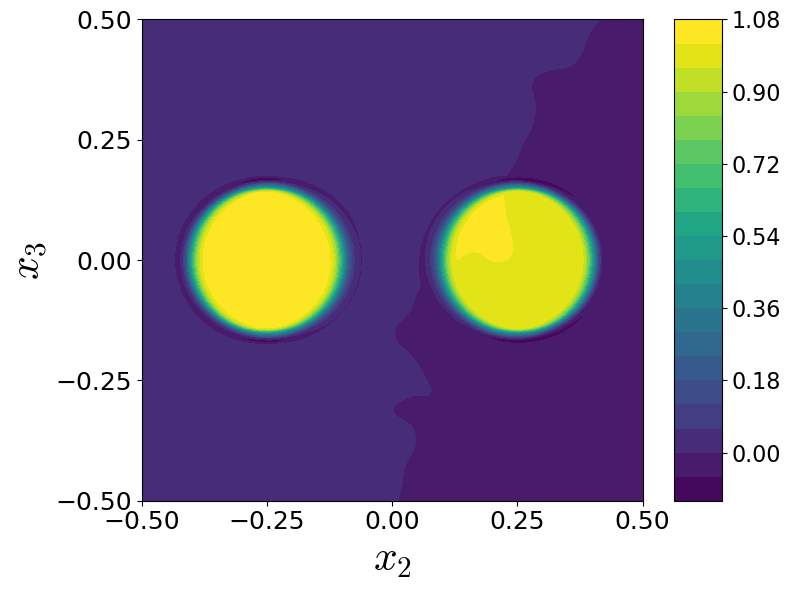

Plot saved as ./noise=5%/visual/ex4.9_S_true_x2_mid.pdf


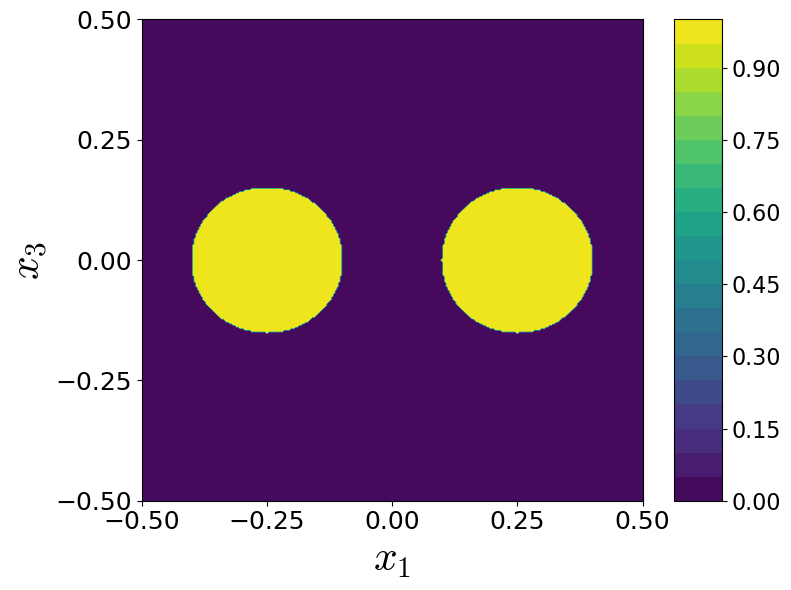

Plot saved as ./noise=5%/visual/ex4.9_S_num_x2_mid.pdf


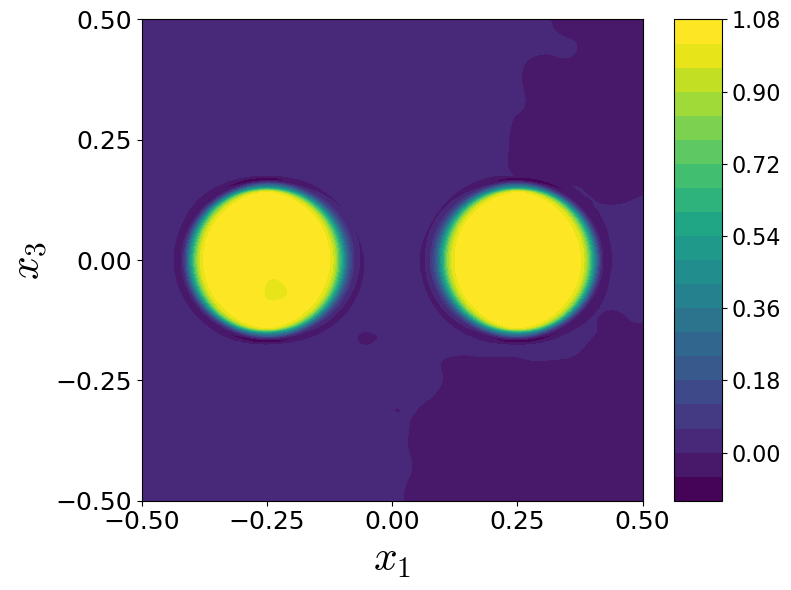

Plot saved as ./noise=5%/visual/ex4.9_S_true_x3_mid.pdf


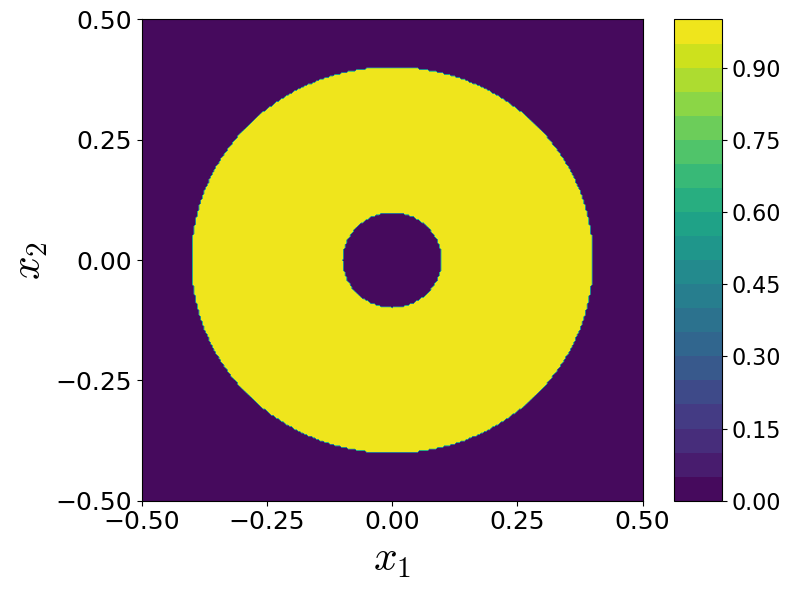

Plot saved as ./noise=5%/visual/ex4.9_S_num_x3_mid.pdf


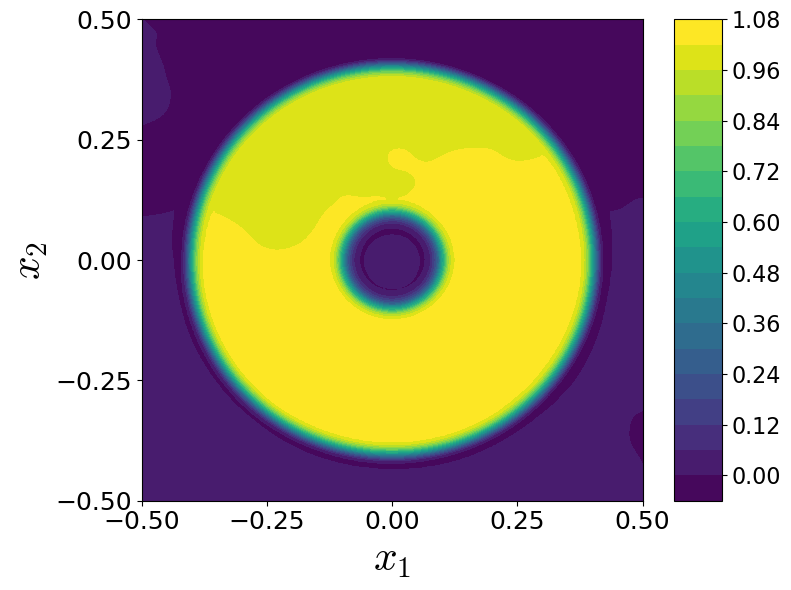

In [23]:
import visual
reload(visual)
output_dictionary="./noise=5%/visual/"
visual.draw(YY,ZZ,S_true_x1_mid,[],"$x_2$","$x_3$",[],"viridis",[-0.5,-0.25,0.0,0.25,0.5],[-0.5,-0.25,0.0,0.25,0.5],output_dictionary,"S_true_x1_mid.pdf","")
visual.draw(YY,ZZ,S_num_x1_mid,[],"$x_2$","$x_3$",[],"viridis",[-0.5,-0.25,0.0,0.25,0.5],[-0.5,-0.25,0.0,0.25,0.5],output_dictionary,"S_num_x1_mid.pdf","")
visual.draw(XX,ZZ,S_true_x2_mid,[],"$x_1$","$x_3$",[],"viridis",[-0.5,-0.25,0.0,0.25,0.5],[-0.5,-0.25,0.0,0.25,0.5],output_dictionary,"S_true_x2_mid.pdf","")
visual.draw(XX,ZZ,S_num_x2_mid,[],"$x_1$","$x_3$",[],"viridis",[-0.5,-0.25,0.0,0.25,0.5],[-0.5,-0.25,0.0,0.25,0.5],output_dictionary,"S_num_x2_mid.pdf","")
visual.draw(XX,ZZ,S_true_x3_mid,[],"$x_1$","$x_2$",[],"viridis",[-0.5,-0.25,0.0,0.25,0.5],[-0.5,-0.25,0.0,0.25,0.5],output_dictionary,"S_true_x3_mid.pdf","")
visual.draw(XX,ZZ,S_num_x3_mid,[],"$x_1$","$x_2$",[],"viridis",[-0.5,-0.25,0.0,0.25,0.5],[-0.5,-0.25,0.0,0.25,0.5],output_dictionary,"S_num_x3_mid.pdf","")
# visual.draw(X,Y,np.abs(S_true-S_num_5),output_dictionary,"abs_S")

In [24]:
g_S=np.load("./noise=5%/g_S.npy")
S_num_store=np.load("./noise=5%/S_num_store.npy",allow_pickle=True)


def center_from_results_or_q_mask(grad, S_num, domain_min, domain_max, para_grad, para_abs, result_name="results"):
    detected_results = globals().get(result_name)
    if detected_results:
        return np.atleast_2d(detected_results[0]["params"]["center"])

    grad_arr = np.asarray(grad)
    s_arr = np.asarray(S_num)
    if grad_arr.shape != s_arr.shape:
        raise ValueError(f"grad shape {grad_arr.shape} does not match S_num shape {s_arr.shape}")

    grad_threshold = np.max(grad_arr) / para_grad
    abs_threshold = np.max(np.abs(s_arr)) / para_abs
    mask = (grad_arr > grad_threshold) & (np.abs(s_arr) > abs_threshold)
    mask_indices = np.array(np.where(mask)).T
    if len(mask_indices) == 0:
        raise ValueError("No Q points detected; adjust para_grad/para_abs.")

    domain_min = np.asarray(domain_min, dtype=float)
    domain_max = np.asarray(domain_max, dtype=float)
    scales = (domain_max - domain_min) / (np.asarray(grad_arr.shape, dtype=float) - 1)
    q_points = domain_min + mask_indices * scales
    return np.atleast_2d(q_points.mean(axis=0))


Global volume range: [0.000, 1.000], using level=0.500


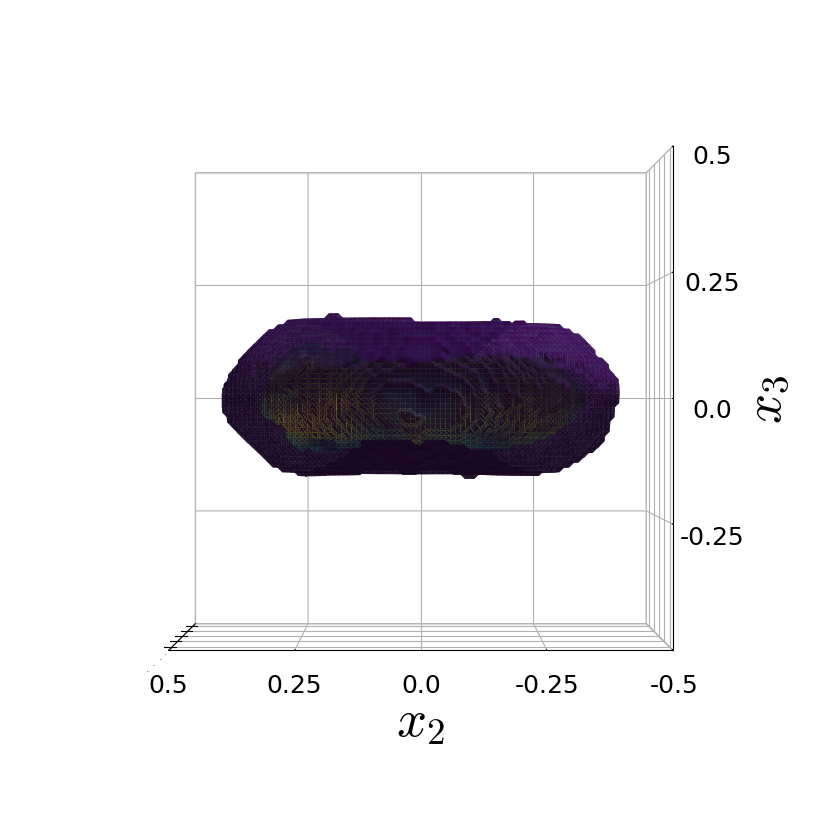

In [48]:
import visual
reload(visual)
dpi=100

center = center_from_results_or_q_mask(g_S, S_num_store[-1], [-0.5,-0.5,-0.5], [0.5,0.5,0.5], 3, 3)
ticks = [-0.5, -0.25, 0.0, 0.25, 0.5]

mapped_mask_points,min_x_point,max_x_point,min_y_point,max_y_point,min_z_point,max_z_point = visual.detect_3d(
    g_S, S_num_store[-1],
    [-0.5,-0.5,-0.5], [0.5,0.5,0.5],
    3, 3,
    0, 180, center, "S", "x1",
    output_directory="./noise=5%/visual/",
    output_filename="plot_3d_straight.pdf",
    dpi=dpi,
    render_mode="surface_only",
    show_colorbar=False,
    xlabel=r"$x_1$",
    ylabel=r"$x_2$",
    zlabel=r"$x_3$",
    x_ticks=ticks,
    y_ticks=ticks,
    z_ticks=ticks,
    axis_label_size=38,
    x_tick_pad=8,
    y_tick_pad=5,
    z_tick_pad=14,
    x_label_pad=15,
    y_label_pad=18,
    z_label_pad=30,
    axis_tick_size=18,
    hide_duplicate_corner_ticks=True,
    surface_stride=1,
    surface_rasterized=True,
)


Global volume range: [0.000, 1.000], using level=0.500


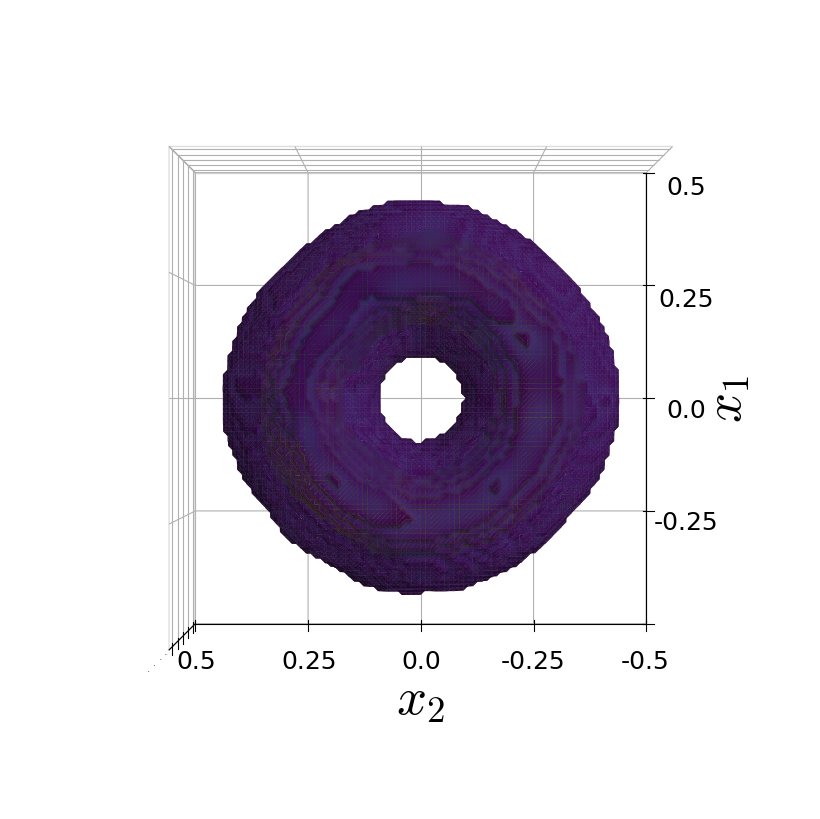

In [47]:
import visual
reload(visual)
dpi=100

center = center_from_results_or_q_mask(g_S, S_num_store[-1], [-0.5,-0.5,-0.5], [0.5,0.5,0.5], 3, 3)
ticks = [-0.5, -0.25, 0.0, 0.25, 0.5]

mapped_mask_points,min_x_point,max_x_point,min_y_point,max_y_point,min_z_point,max_z_point = visual.detect_3d(
    g_S, S_num_store[-1],
    [-0.5,-0.5,-0.5], [0.5,0.5,0.5],
    3, 3,
    90, 180, center, "S", "x3",
    output_directory="./noise=5%/visual/",
    output_filename="plot_3d_top.pdf",
    dpi=dpi,
    render_mode="surface_only",
    show_colorbar=False,
    xlabel=r"$x_1$",
    ylabel=r"$x_2$",
    zlabel=r"$x_3$",
    x_ticks=ticks,
    y_ticks=ticks,
    z_ticks=ticks,
    axis_label_size=38,
    x_tick_pad=20,
    y_tick_pad=10,
    z_tick_pad=8,
    x_label_pad=36,
    y_label_pad=32,
    z_label_pad=25,
    axis_tick_size=18,
    hide_duplicate_corner_ticks=True,
    surface_stride=1,
    surface_rasterized=True,
)


Global volume range: [0.000, 1.000], using level=0.500


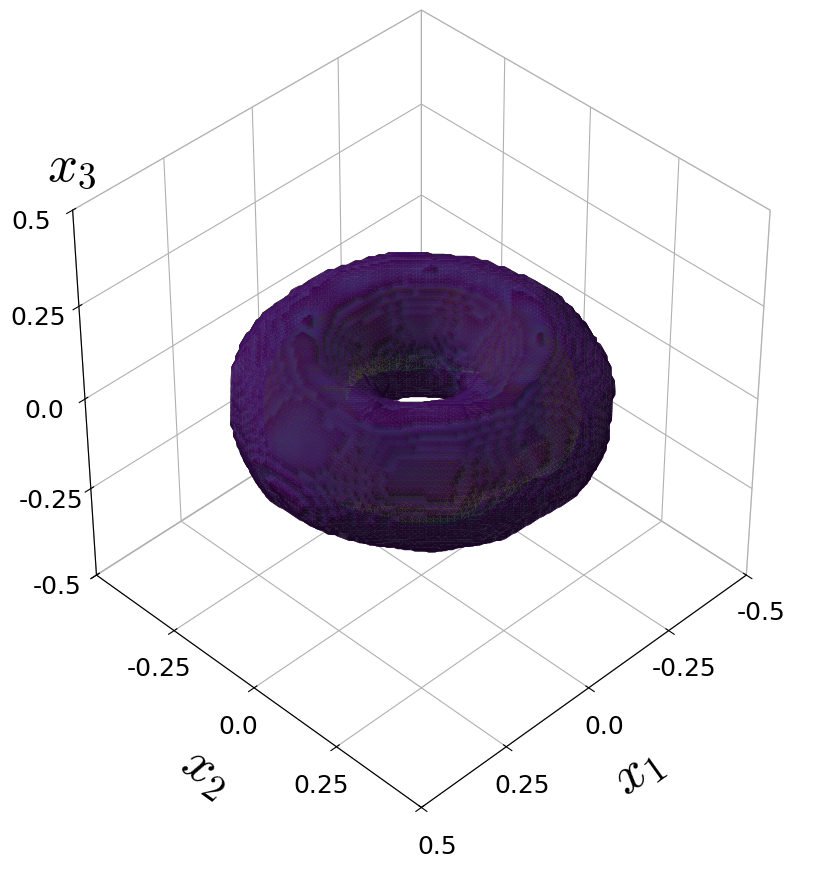

In [46]:
import visual
reload(visual)
dpi=100

center = center_from_results_or_q_mask(g_S, S_num_store[-1], [-0.5,-0.5,-0.5], [0.5,0.5,0.5], 3, 3)
ticks = [-0.5, -0.25, 0.0, 0.25, 0.5]

mapped_mask_points,min_x_point,max_x_point,min_y_point,max_y_point,min_z_point,max_z_point = visual.detect_3d(
    g_S, S_num_store[-1],
    [-0.5,-0.5,-0.5], [0.5,0.5,0.5],
    3, 3,
    40, 45, center, "S", None,
    output_directory="./noise=5%/visual/",
    output_filename="plot_3d_tily.pdf",
    dpi=dpi,
    render_mode="surface_only",
    show_colorbar=False,
    xlabel=r"$x_1$",
    ylabel=r"$x_2$",
    zlabel=r"$x_3$",
    x_ticks=ticks,
    y_ticks=ticks,
    z_ticks=ticks,
    x_tick_pad=6,
    y_tick_pad=6,
    z_tick_pad=10,
    x_label_pad=22,
    y_label_pad=22,
    z_label_pad=25,
    zlabel_position="axis_top",
    axis_label_size=38,
    axis_tick_size=18,
    hide_duplicate_corner_ticks=True,
    surface_stride=1,
    surface_rasterized=True,
)


In [28]:
S_num_1=np.load("./noise=5%/S_num.npy")
g_S1=np.load("./noise=5%/g_S1.npy")

Global volume range: [0.000, 1.000], using level=0.500


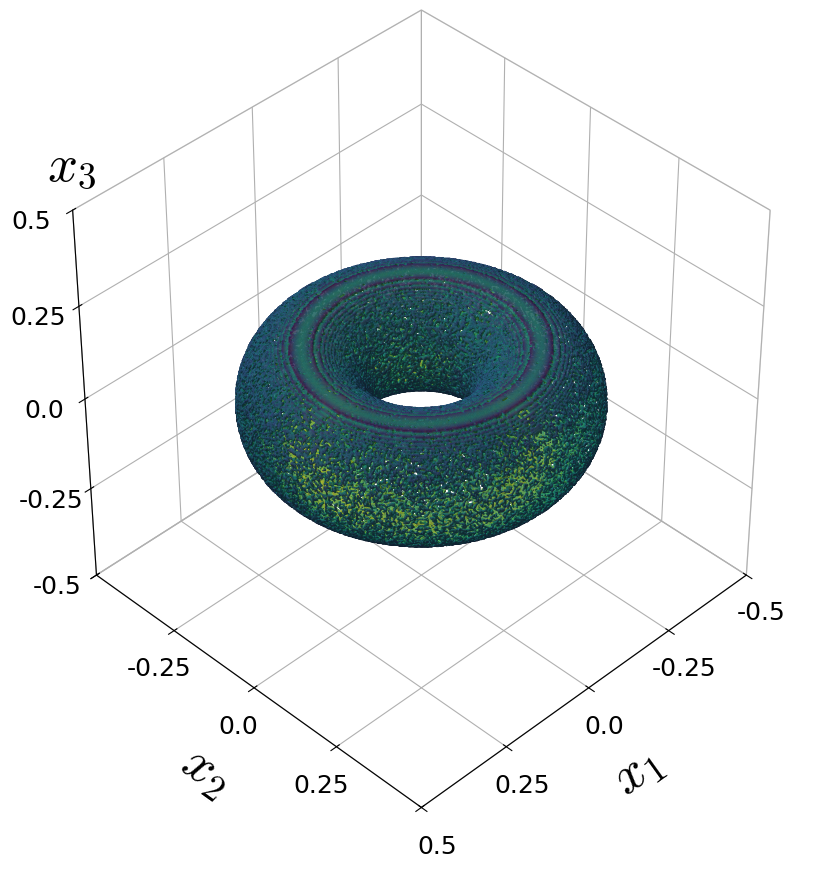

In [42]:
import visual
reload(visual)
dpi=100

center = center_from_results_or_q_mask(g_S1, S_num_1, [-0.5,-0.5,-0.5], [0.5,0.5,0.5], 20, 1.3, result_name="results1")
ticks = [-0.5, -0.25, 0.0, 0.25, 0.5]

mapped_mask_points,min_x_point,max_x_point,min_y_point,max_y_point,min_z_point,max_z_point = visual.detect_3d(
    g_S1, S_num_1,
    [-0.5,-0.5,-0.5], [0.5,0.5,0.5],
    20, 1.3,
    40, 45, center, "S", None,
    output_directory="./noise=5%/visual/",
    output_filename="plot_3d_tily1.pdf",
    dpi=dpi,
    render_mode="surface_only",
    show_colorbar=False,
    xlabel=r"$x_1$",
    ylabel=r"$x_2$",
    zlabel=r"$x_3$",
    x_ticks=ticks,
    y_ticks=ticks,
    z_ticks=ticks,
    x_tick_pad=6,
    y_tick_pad=6,
    z_tick_pad=10,
    x_label_pad=22,
    y_label_pad=22,
    z_label_pad=25,
    zlabel_position="axis_top",
    axis_label_size=38,
    axis_tick_size=18,
    hide_duplicate_corner_ticks=True,
    surface_rasterized=True,
    surface_stride=1,
)


Global volume range: [0.000, 1.000], using level=0.500


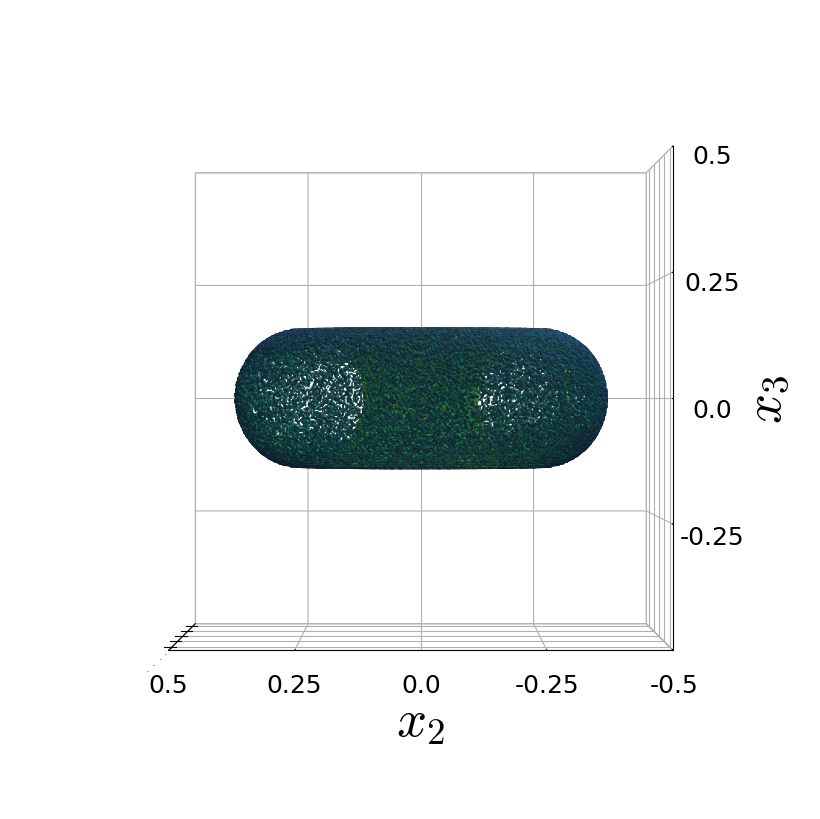

In [44]:
import visual
reload(visual)
dpi=100

center = center_from_results_or_q_mask(g_S1, S_num_1, [-0.5,-0.5,-0.5], [0.5,0.5,0.5], 20, 1.3, result_name="results1")
ticks = [-0.5, -0.25, 0.0, 0.25, 0.5]

mapped_mask_points,min_x_point,max_x_point,min_y_point,max_y_point,min_z_point,max_z_point = visual.detect_3d(
    g_S1, S_num_1,
    [-0.5,-0.5,-0.5], [0.5,0.5,0.5],
    20, 1.3,
    0, 180, center, "S", "x1",
    output_directory="./noise=5%/visual/",
    output_filename="plot_3d_straight1.pdf",
    dpi=dpi,
    render_mode="surface_only",
    show_colorbar=False,
    xlabel=r"$x_1$",
    ylabel=r"$x_2$",
    zlabel=r"$x_3$",
    x_ticks=ticks,
    y_ticks=ticks,
    z_ticks=ticks,
    axis_label_size=38,
    x_tick_pad=8,
    y_tick_pad=5,
    z_tick_pad=14,
    x_label_pad=15,
    y_label_pad=18,
    z_label_pad=30,
    axis_tick_size=18,
    hide_duplicate_corner_ticks=True,
    surface_stride=1,
    surface_rasterized=True,
)


Global volume range: [0.000, 1.000], using level=0.500


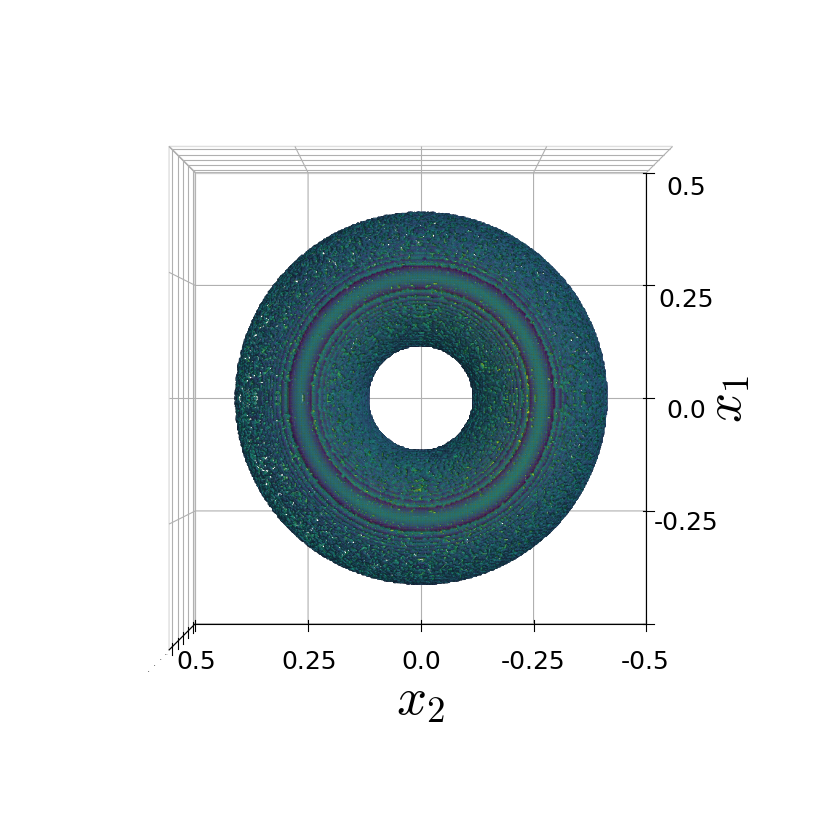

In [45]:
import visual
reload(visual)
dpi=100

center = center_from_results_or_q_mask(g_S1, S_num_1, [-0.5,-0.5,-0.5], [0.5,0.5,0.5], 20, 1.3, result_name="results1")
ticks = [-0.5, -0.25, 0.0, 0.25, 0.5]

mapped_mask_points,min_x_point,max_x_point,min_y_point,max_y_point,min_z_point,max_z_point = visual.detect_3d(
    g_S1, S_num_1,
    [-0.5,-0.5,-0.5], [0.5,0.5,0.5],
    20, 1.3,
    90, 180, center, "S", "x3",
    output_directory="./noise=5%/visual/",
    output_filename="plot_3d_top1.pdf",
    dpi=dpi,
    render_mode="surface_only",
    show_colorbar=False,
    xlabel=r"$x_1$",
    ylabel=r"$x_2$",
    zlabel=r"$x_3$",
    x_ticks=ticks,
    y_ticks=ticks,
    z_ticks=ticks,
    axis_label_size=38,
    x_tick_pad=20,
    y_tick_pad=10,
    z_tick_pad=8,
    x_label_pad=36,
    y_label_pad=32,
    z_label_pad=25,
    axis_tick_size=18,
    hide_duplicate_corner_ticks=True,
    surface_stride=1,
    surface_rasterized=True,
)
